# Labsense SQL Plots Between Two Timestamps

This notebook loads SQL data between `START_TS` and `END_TS` and reuses existing Labsense dashboard plotting functions.

Notes:
- It uses `Labsense_SQL.sql_helpers` for SQL environment and connection string setup.
- Existing dashboard plotting functions include their own internal "recent window" filters:
  - Electricity: last two years for daily trends and previous day for one subplot.
  - Water: last two months.
  - Fumehood: last 7 days.
- To see all expected plots, choose a timestamp window that overlaps those periods.

In [13]:
from pathlib import Path
import os
import sys

import pandas as pd
import pyodbc
from dotenv import load_dotenv
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    """Walk upward until the folder containing Labsense_SQL is found."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Labsense_SQL").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing Labsense_SQL")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Labsense_SQL import sql_helpers
from Labsense_SQL.consumption_dashboard import (
    CALCULATE_IDLE_POWER,
    calculate_idle_power,
    create_plots as create_consumption_plots,
)
from Labsense_SQL.Fumehood_dashboard import (
    FUMEHOOD_CALIBRATION,
    calculate_sash_percentage_open,
    get_display_label,
)
from Labsense_SQL.presence_utils import get_room_light_presence_data
from Labsense_SQL.water_dashboard import create_plots as create_water_plots

# Force-load the .env from Labsense_SQL
env_path = repo_root / "Labsense_SQL" / ".env"
if env_path.exists():
    load_dotenv(dotenv_path=env_path, override=True)
else:
    print(f"Warning: .env not found at {env_path}")

# Keep helper behavior as well (safe no-op if already loaded)
sql_helpers._load_sql_env()


def read_sql_df(
    connection, query: str, start_ts: pd.Timestamp, end_ts: pd.Timestamp
) -> pd.DataFrame:
    """Run a bounded SQL query and coerce Timestamp/Datestamp columns to datetime."""
    df = pd.read_sql(
        query,
        connection,
        params=[start_ts.to_pydatetime(), end_ts.to_pydatetime()],
    )
    if "Timestamp" in df.columns:
        df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    if "Datestamp" in df.columns:
        df["Datestamp"] = pd.to_datetime(df["Datestamp"])
    return df


def build_connection_string_with_driver_fallback() -> str:
    """Build SQL connection string using installed ODBC drivers."""
    sql_server = os.getenv("SQL_SERVER", "MSM-FPM-70203\\LABSENSE").strip()
    sql_database = os.getenv("SQL_DATABASE", "labsense").strip()
    sql_trusted = os.getenv("SQL_TRUSTED_CONNECTION", "yes").strip().lower()
    sql_encrypt = os.getenv("SQL_ENCRYPTION", "Optional").strip()
    sql_user = os.getenv("SQL_USER", "").strip()
    sql_password = os.getenv("SQL_PASSWORD", "").strip()

    available_drivers = pyodbc.drivers()
    preferred_driver = os.getenv("SQL_DRIVER", "ODBC Driver 18 for SQL Server").strip()
    driver_candidates = [
        preferred_driver,
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "SQL Server",
    ]
    selected_driver = next(
        (d for d in driver_candidates if d in available_drivers), None
    )

    if selected_driver is None:
        if not available_drivers:
            raise RuntimeError("No ODBC drivers found. Install SQL Server ODBC driver.")
        selected_driver = available_drivers[0]

    if sql_trusted == "yes":
        conn = (
            f"DRIVER={{{selected_driver}}};"
            f"SERVER={sql_server};"
            f"DATABASE={sql_database};"
            "Trusted_Connection=yes;"
            f"Encrypt={sql_encrypt}"
        )
    else:
        if not sql_user or not sql_password:
            raise ValueError(
                "SQL_USER and SQL_PASSWORD must be set when SQL_TRUSTED_CONNECTION is not 'yes'."
            )
        conn = (
            f"DRIVER={{{selected_driver}}};"
            f"SERVER={sql_server};"
            f"DATABASE={sql_database};"
            f"UID={sql_user};"
            f"PWD={sql_password};"
            f"Encrypt={sql_encrypt}"
        )

    print(f"Loaded .env: {env_path}")
    print(f"Using ODBC driver: {selected_driver}")
    print(f"SQL server/database: {sql_server} / {sql_database}")
    return conn


connection_string = build_connection_string_with_driver_fallback()

# --- User parameters ---
START_TS = pd.Timestamp("2026-05-11 00:00:00")
END_TS = pd.Timestamp("2026-05-15 23:59:59")
PRESENCE_LAB_ID = 1
PRESENCE_SUBLAB_ID = 3

if END_TS <= START_TS:
    raise ValueError("END_TS must be later than START_TS")

PLOT_DIR = repo_root / "plots" / f"notebook_{START_TS:%Y%m%d_%H%M}_{END_TS:%Y%m%d_%H%M}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using SQL window: {START_TS} -> {END_TS}")
print(f"Plot output dir: {PLOT_DIR}")

Loaded .env: C:\Users\fpm-admin\src\labsense\Labsense_SQL\.env
Using ODBC driver: ODBC Driver 18 for SQL Server
SQL server/database: MSM-FPM-70203\LABSENSE / labsense
Using SQL window: 2026-05-11 00:00:00 -> 2026-05-15 23:59:59
Plot output dir: C:\Users\fpm-admin\src\labsense\plots\notebook_20260511_0000_20260515_2359


## 2. Fumehood Comparison

Builds the two-date fumehood sash and light comparison for presentation, using calibrated sash openings and a shared time-of-day axis.

C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_35024\1319870463.py:53: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


No single hood had both requested dates; using the first available hood and leaving missing panels blank.


C:\Users\fpm-admin\AppData\Local\Temp\ipykernel_35024\1677883958.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


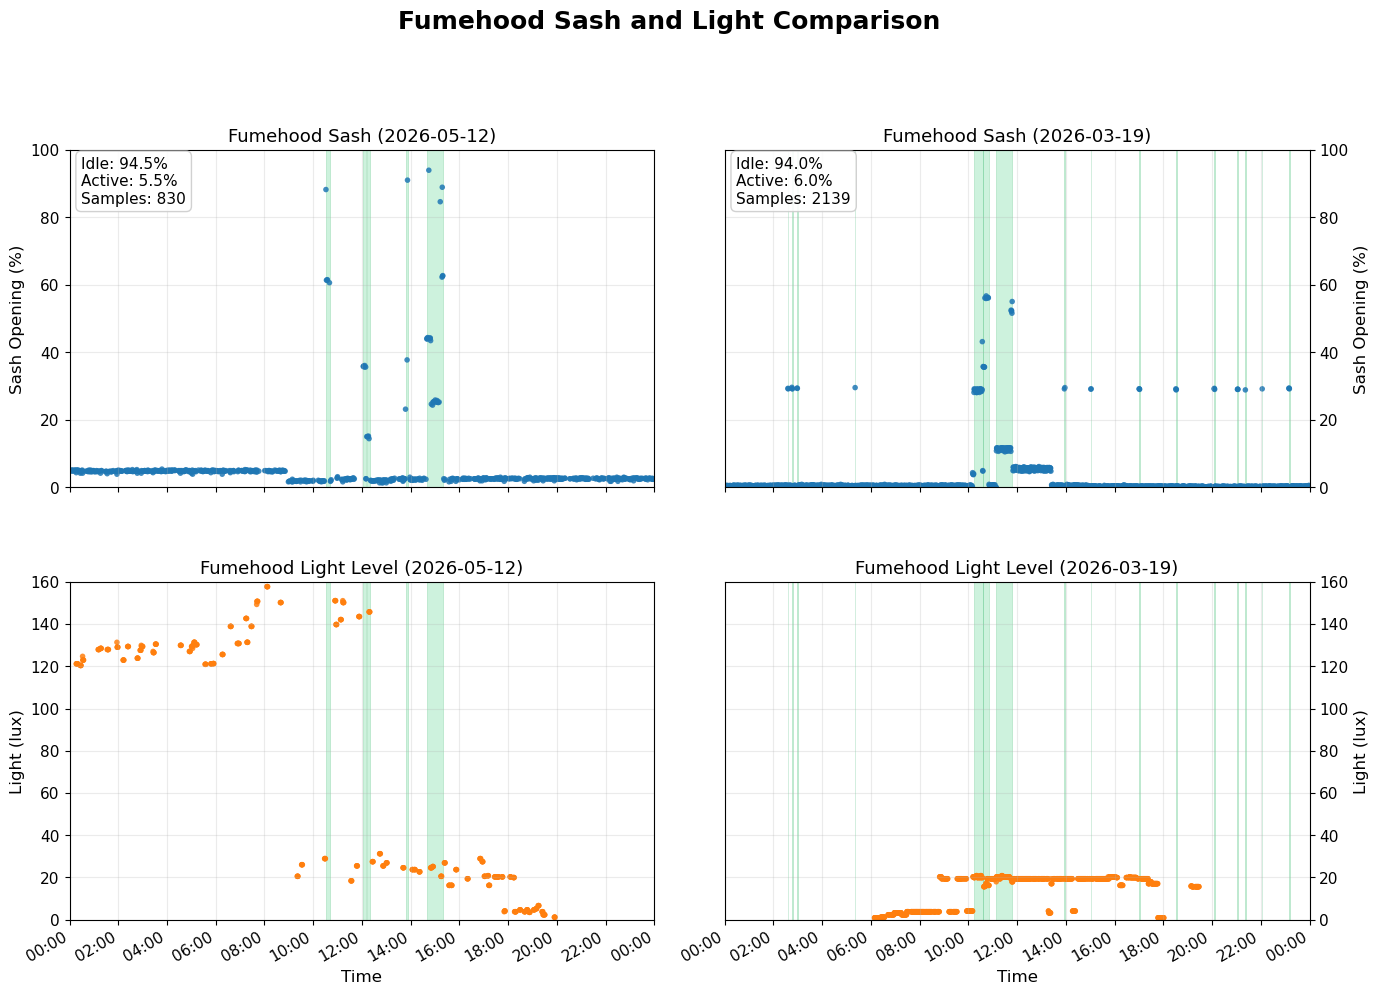

Fumehood custom plots: 1
Fumehood raw plots: 0


In [27]:
# Four-panel fumehood comparison for two specific dates.
fumehood_plot_files = {}
fumehood_raw_plot_files = {}
target_dates = [pd.Timestamp("2026-05-12"), pd.Timestamp("2026-03-19")]
target_start = min(target_dates)
target_end = max(target_dates) + pd.Timedelta(days=1)

with pyodbc.connect(connection_string) as conn:
    target_fumehood = read_sql_df(
        conn,
        """
        SELECT id, LabId, SubLabId, Distance, Light, Airflow, Timestamp
        FROM dbo.fumehood
        WHERE Timestamp >= ? AND Timestamp < ?
        ORDER BY Timestamp ASC
        """,
        target_start,
        target_end,
    )

if target_fumehood.empty:
    print("No fumehood records were found for the requested dates.")
else:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt

    # Use TrueType font embedding so PDF text stays editable in Adobe Illustrator.
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    excluded_distance_ranges = [
        {"min": 530, "max": 567},
        {"min": 265, "max": 290},
        {"min": 365, "max": 385},
    ]

    def in_excluded_distance_range(distance: float) -> bool:
        return any(
            distance_range["min"] <= distance <= distance_range["max"]
            for distance_range in excluded_distance_ranges
        )

    def shade_sash_open_intervals(ax_list, open_df: pd.DataFrame):
        if open_df.empty:
            return

        open_df = open_df.sort_values(by=["Timestamp"]).reset_index(drop=True).copy()
        time_gaps = open_df["Timestamp"].diff().dropna()
        if time_gaps.empty or pd.isna(time_gaps.median()):
            typical_gap = pd.Timedelta(minutes=5)
        else:
            typical_gap = pd.Timedelta(time_gaps.median())
        gap_threshold = max(pd.Timedelta(minutes=30), typical_gap * 3)

        i = 0
        while i < len(open_df):
            if not bool(open_df.loc[i, "SashOpen"]):
                i += 1
                continue

            start = open_df.loc[i, "Timestamp"]
            j = i
            while j + 1 < len(open_df):
                next_gap = open_df.loc[j + 1, "Timestamp"] - open_df.loc[j, "Timestamp"]
                if not bool(open_df.loc[j + 1, "SashOpen"]) or next_gap > gap_threshold:
                    break
                j += 1

            end = open_df.loc[j, "Timestamp"] + typical_gap
            for ax in ax_list:
                ax.axvspan(
                    start,
                    end,
                    facecolor="#2ecc71",
                    edgecolor="#27ae60",
                    linewidth=0.6,
                    alpha=0.24,
                    zorder=0,
                )
            i = j + 1

    def calibrated_idle_active_text(series: pd.Series) -> str:
        valid = pd.to_numeric(series, errors="coerce").dropna()
        if valid.empty:
            return "Idle: n/a\nActive: n/a\nSamples: 0"
        active_pct = (valid >= 10.0).mean() * 100.0
        idle_pct = 100.0 - active_pct
        return (
            f"Idle: {idle_pct:.1f}%\nActive: {active_pct:.1f}%\nSamples: {len(valid)}"
        )

    hood_day_counts = (
        target_fumehood.assign(Date=target_fumehood["Timestamp"].dt.normalize())
        .groupby(["LabId", "SubLabId", "Date"])
        .size()
        .reset_index(name="rows")
    )
    hood_pairs_with_both_days = (
        hood_day_counts.groupby(["LabId", "SubLabId"])["Date"]
        .nunique()
        .loc[lambda counts: counts == len(target_dates)]
        .index.tolist()
    )

    if hood_pairs_with_both_days:
        target_lab_id, target_sublab_id = hood_pairs_with_both_days[0]
    else:
        fallback_pair = (
            target_fumehood[["LabId", "SubLabId"]]
            .drop_duplicates()
            .sort_values(by=["LabId", "SubLabId"])
            .iloc[0]
        )
        target_lab_id = int(fallback_pair["LabId"])
        target_sublab_id = int(fallback_pair["SubLabId"])
        print(
            "No single hood had both requested dates; using the first available hood and leaving missing panels blank.",
        )

    hood_df = (
        target_fumehood[
            (target_fumehood["LabId"] == target_lab_id)
            & (target_fumehood["SubLabId"] == target_sublab_id)
        ]
        .sort_values(by=["Timestamp"])
        .copy()
    )
    hood_label = get_display_label(target_lab_id, target_sublab_id)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        sharex=True,
        sharey="row",
        gridspec_kw={"hspace": 0.28, "wspace": 0.12},
    )
    fig.suptitle(
        "Fumehood Sash and Light Comparison",
        fontsize=18,
        fontweight="bold",
        y=1.02,
    )

    baseline_start = pd.Timestamp("2000-01-01")
    baseline_end = baseline_start + pd.Timedelta(days=1)

    for col, day_start in enumerate(target_dates):
        day_end = day_start + pd.Timedelta(days=1)
        day_hood_df = hood_df[
            (hood_df["Timestamp"] >= day_start) & (hood_df["Timestamp"] < day_end)
        ].copy()

        ax_sash = axes[0, col]
        ax_light = axes[1, col]

        if day_hood_df.empty:
            ax_sash.axis("off")
            ax_light.axis("off")
            ax_sash.set_title(f"No data for {day_start:%Y-%m-%d}")
            continue

        sash_df = day_hood_df[
            ~day_hood_df["Distance"].apply(in_excluded_distance_range)
        ].copy()
        light_values = pd.to_numeric(day_hood_df["Light"], errors="coerce")
        light_plot_df = day_hood_df[light_values > 0].copy()

        plot_offset = pd.Timestamp("2000-01-01") - day_start
        sash_plot_time = sash_df["Timestamp"] + plot_offset
        light_plot_time = light_plot_df["Timestamp"] + plot_offset

        calibrated = (
            target_lab_id,
            target_sublab_id,
        ) in FUMEHOOD_CALIBRATION and not sash_df.empty
        if calibrated:
            sash_series = sash_df["Distance"].apply(
                lambda d: calculate_sash_percentage_open(
                    d, target_lab_id, target_sublab_id
                )
            )
            sash_mask = sash_series.notna()
            ax_sash.scatter(
                sash_plot_time.loc[sash_mask],
                sash_series.loc[sash_mask],
                color="#1f77b4",
                s=16,
                alpha=0.85,
                edgecolors="none",
            )
            ax_sash.set_ylabel("Sash Opening (%)", fontsize=12)
            ax_sash.set_ylim(0, 100)

            open_df = sash_df.loc[sash_mask, ["Timestamp"]].copy()
            open_df["SashOpen"] = sash_series.loc[sash_mask] > 10.0
            open_df["Timestamp"] = open_df["Timestamp"] + plot_offset
            shade_sash_open_intervals([ax_sash, ax_light], open_df)
            stats_text = calibrated_idle_active_text(sash_series.loc[sash_mask])
        elif not sash_df.empty:
            ax_sash.scatter(
                sash_plot_time,
                sash_df["Distance"],
                color="#1f77b4",
                s=16,
                alpha=0.85,
                edgecolors="none",
            )
            ax_sash.set_ylabel("Sash Opening (mm)", fontsize=12)
            stats_text = "Idle: n/a\nActive: n/a\nSamples: n/a"
        else:
            ax_sash.set_ylabel("Sash Opening", fontsize=12)
            stats_text = "Idle: n/a\nActive: n/a\nSamples: 0"

        ax_sash.text(
            0.02,
            0.98,
            stats_text,
            transform=ax_sash.transAxes,
            va="top",
            ha="left",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": "#cccccc",
                "alpha": 0.9,
            },
        )
        ax_sash.set_title(
            f"Fumehood Sash ({day_start:%Y-%m-%d})",
            fontsize=13,
        )
        ax_sash.grid(True, alpha=0.25)
        ax_sash.tick_params(axis="x", labelbottom=False)
        ax_sash.set_xlim(baseline_start, baseline_end)

        ax_light.scatter(
            light_plot_time,
            light_plot_df["Light"],
            color="#ff7f0e",
            s=16,
            alpha=0.85,
            edgecolors="none",
        )
        ax_light.set_ylabel("Light (lux)", fontsize=12)
        ax_light.set_xlabel("Time", fontsize=12)
        ax_light.set_title(
            f"Fumehood Light Level ({day_start:%Y-%m-%d})",
            fontsize=13,
        )
        ax_light.grid(True, alpha=0.25)
        ax_light.set_xlim(baseline_start, baseline_end)
        ax_light.set_ylim(0, 160)

        for ax in (ax_sash, ax_light):
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.tick_params(axis="both", labelsize=11)

        if col == 1:
            for ax in (ax_sash, ax_light):
                ax.yaxis.set_label_position("right")
                ax.yaxis.tick_right()
                ax.yaxis.set_ticks_position("right")

        ax_light.tick_params(axis="x", labelbottom=True)
        plt.setp(ax_light.get_xticklabels(), rotation=30, ha="right")

    fig.align_ylabels(axes[:, 0])
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    PLOT_DIR.mkdir(parents=True, exist_ok=True)

    out_name = (
        f"fumehood_four_panel_{target_dates[0]:%Y%m%d}_{target_dates[1]:%Y%m%d}.png"
    )
    out_path = PLOT_DIR / out_name
    out_pdf_path = out_path.with_suffix(".pdf")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    fig.savefig(out_pdf_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fumehood_plot_files["four_panel"] = out_name

print("Fumehood custom plots:", len(fumehood_plot_files))
print("Fumehood raw plots:", len(fumehood_raw_plot_files))

## 4. Electricity Trend (Last Two Years)

Loads two years of daily electricity data and plots raw daily use plus a 7-day moving average with reference date markers.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Match dashboard logic: anchor the two-year window to the first day of the start month.
two_years_ago = datetime.now() - timedelta(days=730)
last_two_years_start = pd.Timestamp(
    two_years_ago.replace(day=1, hour=0, minute=0, second=0, microsecond=0)
)

with pyodbc.connect(connection_string) as conn:
    df_elec_daily_two_years = pd.read_sql(
        """
        SELECT id, Esum, Datestamp
        FROM dbo.elecDaily
        WHERE Datestamp >= ?
        ORDER BY Datestamp ASC
        """,
        conn,
        params=[last_two_years_start.to_pydatetime()],
    )

df_elec_daily_two_years["Datestamp"] = pd.to_datetime(
    df_elec_daily_two_years["Datestamp"], errors="coerce"
)
df_elec_daily_two_years = df_elec_daily_two_years.dropna(subset=["Datestamp", "Esum"])

if df_elec_daily_two_years.empty:
    print(f"No elecDaily data found since {last_two_years_start:%Y-%m-%d}.")
else:
    # Use TrueType font embedding so PDF text stays editable in Adobe Illustrator.
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    df_plot = df_elec_daily_two_years.sort_values(by=["Datestamp"]).copy()
    df_plot["Esum_7d_ma"] = df_plot["Esum"].rolling(window=7, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        df_plot["Datestamp"],
        df_plot["Esum"],
        marker="o",
        linestyle="-",
        linewidth=2,
        markersize=4,
        color="#3498db",
        label="Daily Consumption",
    )
    ax.plot(
        df_plot["Datestamp"],
        df_plot["Esum_7d_ma"],
        linestyle="--",
        linewidth=2.5,
        color="#e67e22",
        label="7-Day Moving Average",
    )

    # Requested reference dates.
    ref_date_1 = pd.Timestamp("2025-04-11")
    ref_date_2 = pd.Timestamp("2025-04-28")
    ax.axvline(
        ref_date_1, color="#c0392b", linestyle=":", linewidth=2, label="11/04/25"
    )
    ax.axvline(
        ref_date_2, color="#8e44ad", linestyle=":", linewidth=2, label="28/04/25"
    )

    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Daily Consumption (kWh)", fontsize=12)
    ax.set_title(
        "Daily Electricity Consumption Trends (Last Two Years)",
        fontsize=14,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=45)
    fig.tight_layout()

    out_pdf = PLOT_DIR / "electricity_consumption_trends_last_two_years.pdf"
    fig.savefig(out_pdf, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_pdf}")
    print(
        f"Rows plotted: {len(df_plot)} (from {df_plot['Datestamp'].min():%Y-%m-%d} to {df_plot['Datestamp'].max():%Y-%m-%d})"
    )

## 5. Christmas Shutdown Savings Estimate

Estimates expected vs actual electricity use during shutdown windows using adjacent baseline periods.

In [ ]:
# Estimate Christmas shutdown energy savings (kWh) using nearby shoulder periods as baseline.
# Labels use the shutdown end-year:
#   2025 shutdown = Dec 2024 to Jan 2025
#   2026 shutdown = Dec 2025 to Jan 2026

shutdown_windows = [
    {
        "label": "Christmas shutdown 2025",
        "start": pd.Timestamp("2024-12-20"),
        "end": pd.Timestamp("2025-01-05"),
    },
    {
        "label": "Christmas shutdown 2026",
        "start": pd.Timestamp("2025-12-20"),
        "end": pd.Timestamp("2026-01-04"),
    },
]

baseline_days = (
    21  # days before and after shutdown window used for expected daily consumption
)
df_daily = df_plot[["Datestamp", "Esum"]].copy()
df_daily["Datestamp"] = pd.to_datetime(df_daily["Datestamp"]).dt.normalize()
df_daily = df_daily.sort_values("Datestamp")

results = []
for win in shutdown_windows:
    start = win["start"]
    end = win["end"]
    label = win["label"]

    shutdown_mask = (df_daily["Datestamp"] >= start) & (df_daily["Datestamp"] <= end)
    shutdown_df = df_daily.loc[shutdown_mask].copy()

    pre_start = start - pd.Timedelta(days=baseline_days)
    pre_end = start - pd.Timedelta(days=1)
    post_start = end + pd.Timedelta(days=1)
    post_end = end + pd.Timedelta(days=baseline_days)

    baseline_pre = df_daily[
        (df_daily["Datestamp"] >= pre_start) & (df_daily["Datestamp"] <= pre_end)
    ]
    baseline_post = df_daily[
        (df_daily["Datestamp"] >= post_start) & (df_daily["Datestamp"] <= post_end)
    ]
    baseline_df = pd.concat([baseline_pre, baseline_post], ignore_index=True)

    if shutdown_df.empty or baseline_df.empty:
        results.append(
            {
                "period": label,
                "shutdown_start": start.date(),
                "shutdown_end": end.date(),
                "days_in_window": int((end - start).days + 1),
                "days_with_data": int(len(shutdown_df)),
                "baseline_days_with_data": int(len(baseline_df)),
                "baseline_kwh_per_day": pd.NA,
                "expected_kwh": pd.NA,
                "actual_kwh": (
                    float(shutdown_df["Esum"].sum()) if not shutdown_df.empty else pd.NA
                ),
                "estimated_saved_kwh": pd.NA,
                "estimated_saved_pct": pd.NA,
            }
        )
        continue

    baseline_kwh_per_day = float(baseline_df["Esum"].mean())
    expected_kwh = baseline_kwh_per_day * len(shutdown_df)
    actual_kwh = float(shutdown_df["Esum"].sum())
    saved_kwh = expected_kwh - actual_kwh
    saved_pct = (saved_kwh / expected_kwh * 100.0) if expected_kwh > 0 else pd.NA

    results.append(
        {
            "period": label,
            "shutdown_start": start.date(),
            "shutdown_end": end.date(),
            "days_in_window": int((end - start).days + 1),
            "days_with_data": int(len(shutdown_df)),
            "baseline_days_with_data": int(len(baseline_df)),
            "baseline_kwh_per_day": baseline_kwh_per_day,
            "expected_kwh": expected_kwh,
            "actual_kwh": actual_kwh,
            "estimated_saved_kwh": saved_kwh,
            "estimated_saved_pct": saved_pct,
        }
    )

savings_df = pd.DataFrame(results)

for col in [
    "baseline_kwh_per_day",
    "expected_kwh",
    "actual_kwh",
    "estimated_saved_kwh",
    "estimated_saved_pct",
]:
    if col in savings_df.columns:
        savings_df[col] = pd.to_numeric(savings_df[col], errors="coerce").round(1)

display(savings_df)

valid_savings = savings_df["estimated_saved_kwh"].dropna()
if not valid_savings.empty:
    print(f"Estimated total Christmas shutdown savings: {valid_savings.sum():,.1f} kWh")
else:
    print("Could not estimate savings: missing shutdown-window or baseline data.")

## 6. Daily Tables Around Shutdown Periods

Creates date-level consumption tables for Dec/Jan windows and selected calendar months for side-by-side inspection.

In [ ]:
# Daily consumption listing for Dec/Jan windows around the 2025 and 2026 shutdown periods.
daily_view = df_plot[["Datestamp", "Esum"]].copy()
daily_view["Datestamp"] = pd.to_datetime(daily_view["Datestamp"]).dt.normalize()
daily_view = daily_view.sort_values("Datestamp")

# Windows used for shutdown interpretation.
window_2025 = daily_view[
    (daily_view["Datestamp"] >= pd.Timestamp("2024-12-19"))
    & (daily_view["Datestamp"] <= pd.Timestamp("2025-01-10"))
].copy()
window_2026 = daily_view[
    (daily_view["Datestamp"] >= pd.Timestamp("2025-12-19"))
    & (daily_view["Datestamp"] <= pd.Timestamp("2026-01-10"))
].copy()


def format_daily_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    out = df.copy()
    out["Date"] = out["Datestamp"].dt.strftime("%Y-%m-%d")
    out["Year"] = out["Datestamp"].dt.year
    out["Month"] = out["Datestamp"].dt.month_name().str.slice(0, 3)
    out["Daily_kWh"] = out["Esum"].round(2)
    out = out[["Date", "Year", "Month", "Daily_kWh"]]
    print(f"\n{label} ({len(out)} rows)")
    return out


display(format_daily_table(window_2025, "Window A: Dec 2024 to Jan 2025"))
display(format_daily_table(window_2026, "Window B: Dec 2025 to Jan 2026"))

# Extra calendar-month extracts for your requested years.
requested_months = [
    (2025, 1),
    (2025, 12),
    (2026, 1),
    (2026, 12),
]

for year, month in requested_months:
    month_df = daily_view[
        (daily_view["Datestamp"].dt.year == year)
        & (daily_view["Datestamp"].dt.month == month)
    ].copy()
    month_name = pd.Timestamp(year=year, month=month, day=1).strftime("%b %Y")
    if month_df.empty:
        print(f"\n{month_name}: no data in current two-year extract.")
    else:
        display(format_daily_table(month_df, f"Calendar month: {month_name}"))

## 7. 90-Day Before/After Electricity Comparison

Compares total and daily electricity metrics in fixed 90-day windows around the two key reference dates.

In [ ]:
# Compare energy consumption using fixed 90-day windows around the reference dates.
before_anchor = pd.Timestamp("2025-04-11")
after_anchor = pd.Timestamp("2025-04-28")
comparison_days = 90

before_end = before_anchor - pd.Timedelta(days=1)
before_start = before_end - pd.Timedelta(days=comparison_days - 1)
after_start = after_anchor + pd.Timedelta(days=1)
after_end = after_start + pd.Timedelta(days=comparison_days - 1)

# Use existing daily table if present; otherwise rebuild from df_plot.
if "daily_view" in globals():
    cmp_daily = daily_view[["Datestamp", "Esum"]].copy()
else:
    cmp_daily = df_plot[["Datestamp", "Esum"]].copy()
    cmp_daily["Datestamp"] = pd.to_datetime(cmp_daily["Datestamp"]).dt.normalize()
cmp_daily = cmp_daily.sort_values("Datestamp")

before_df = cmp_daily[
    (cmp_daily["Datestamp"] >= before_start) & (cmp_daily["Datestamp"] <= before_end)
].copy()
after_df = cmp_daily[
    (cmp_daily["Datestamp"] >= after_start) & (cmp_daily["Datestamp"] <= after_end)
].copy()


def summarize_period(
    df: pd.DataFrame, label: str, start: pd.Timestamp, end: pd.Timestamp
) -> dict:
    return {
        "period": label,
        "window_start": start.date(),
        "window_end": end.date(),
        "calendar_days": int((end - start).days + 1),
        "days_with_data": int(len(df)),
        "total_kwh": float(df["Esum"].sum()) if not df.empty else pd.NA,
        "avg_kwh_per_day": float(df["Esum"].mean()) if not df.empty else pd.NA,
        "median_kwh_per_day": float(df["Esum"].median()) if not df.empty else pd.NA,
        "min_kwh": float(df["Esum"].min()) if not df.empty else pd.NA,
        "max_kwh": float(df["Esum"].max()) if not df.empty else pd.NA,
    }


comparison_df = pd.DataFrame(
    [
        summarize_period(
            before_df, "90 days before 2025-04-11", before_start, before_end
        ),
        summarize_period(after_df, "90 days after 2025-04-28", after_start, after_end),
    ]
)

for c in ["total_kwh", "avg_kwh_per_day", "median_kwh_per_day", "min_kwh", "max_kwh"]:
    comparison_df[c] = pd.to_numeric(comparison_df[c], errors="coerce").round(2)

display(comparison_df)

if len(comparison_df) == 2 and comparison_df["total_kwh"].notna().all():
    total_diff = comparison_df.loc[1, "total_kwh"] - comparison_df.loc[0, "total_kwh"]
    total_pct = (
        total_diff / comparison_df.loc[0, "total_kwh"] * 100
        if comparison_df.loc[0, "total_kwh"] != 0
        else pd.NA
    )
    avg_diff = (
        comparison_df.loc[1, "avg_kwh_per_day"]
        - comparison_df.loc[0, "avg_kwh_per_day"]
    )
    avg_pct = (
        avg_diff / comparison_df.loc[0, "avg_kwh_per_day"] * 100
        if comparison_df.loc[0, "avg_kwh_per_day"] != 0
        else pd.NA
    )

    print(
        f"Total kWh change (after - before): {total_diff:,.2f} kWh ({total_pct:.2f}%)"
    )
    print(f"Average daily kWh change: {avg_diff:,.2f} kWh/day ({avg_pct:.2f}%)")
else:
    print("Comparison incomplete due to missing data in one or both windows.")

## 8. ChemInventory Snapshot Composition

Builds stacked composition plots for ChemInventory categories across selected snapshot dates.

C:\Users\fpm-admin\src\labsense\Labsense_SQL\ChemInventory_dashboard.py:121: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


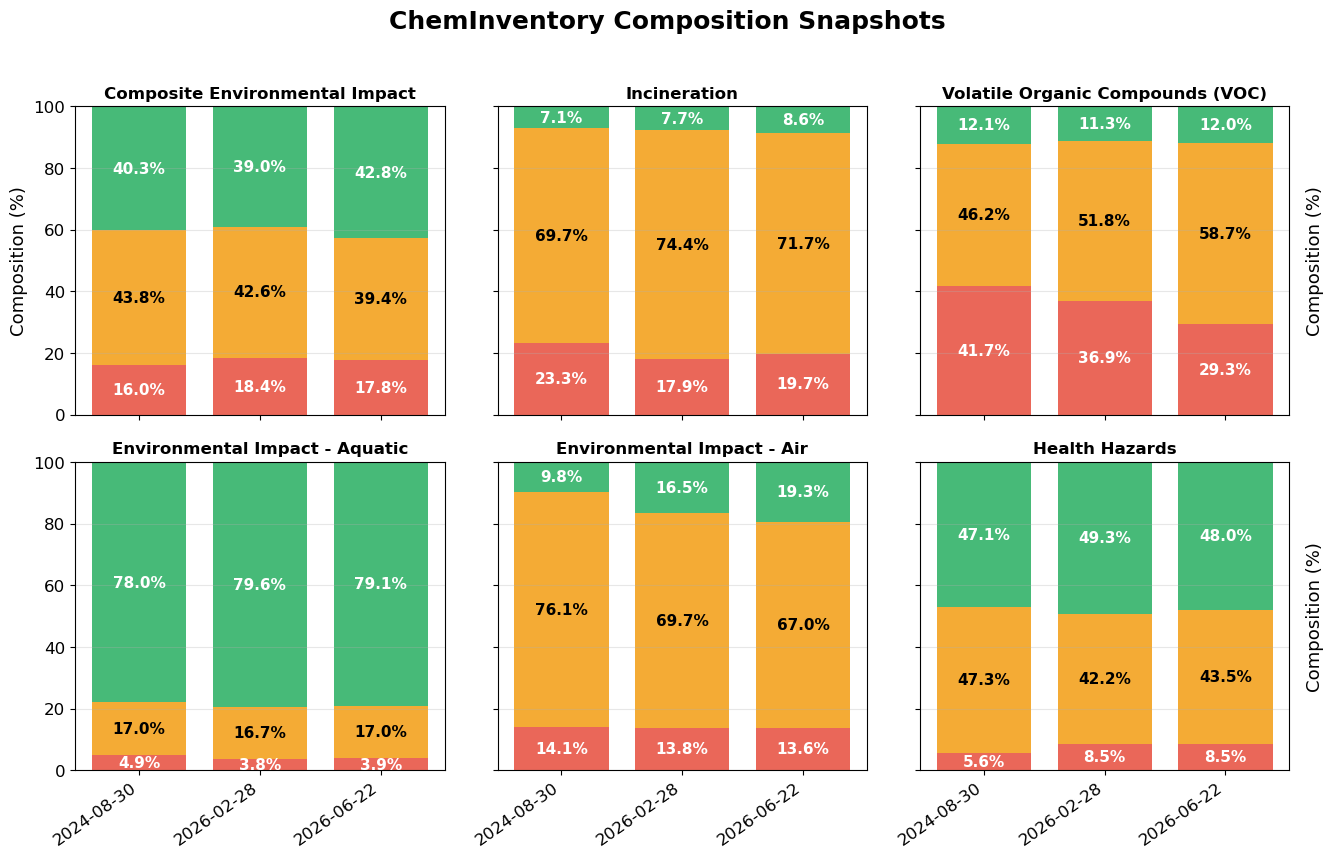

Saved: C:\Users\fpm-admin\src\labsense\plots\cheminventory_snapshots\cheminventory_snapshots.png
Saved: C:\Users\fpm-admin\src\labsense\plots\cheminventory_snapshots\cheminventory_snapshots.pdf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Optional
from Labsense_SQL.ChemInventory_dashboard import (
    CATEGORIES,
    CATEGORY_DISPLAY_NAMES,
    fetch_all_data as fetch_cheminventory_all_data,
)

# Use TrueType font embedding so PDF text stays editable in Adobe Illustrator.
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# --- User parameters: list the specific snapshot dates to compare ---
CHEM_SNAPSHOT_DATES = [
    pd.Timestamp("2024-08-30"),
    pd.Timestamp("2026-02-28"),
    pd.Timestamp("2026-06-22"),
]

# Max gap (days) to search for the nearest record around each target date
CHEM_DATE_TOLERANCE_DAYS = 1

CHEM_PLOT_DIR = repo_root / "plots" / "cheminventory_snapshots"
CHEM_PLOT_DIR.mkdir(parents=True, exist_ok=True)

raw_cheminventory_data = fetch_cheminventory_all_data(connection_string)


def nearest_record(
    df: pd.DataFrame, target: pd.Timestamp, tol_days: int
) -> Optional[dict]:
    """Return % composition for the record in df closest to target (within tol_days)."""
    df = df.copy()
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["_dist"] = (df["Timestamp"] - target).abs()
    nearest = df.nsmallest(1, "_dist")
    if nearest.empty or nearest.iloc[0]["_dist"] > pd.Timedelta(days=tol_days):
        return None
    row = nearest.iloc[0]
    total = row["RedVol"] + row["YellowVol"] + row["GreenVol"]
    safe_total = total if total != 0 else 1
    return {
        "date": row["Timestamp"],
        "red_pct": row["RedVol"] / safe_total * 100,
        "yellow_pct": row["YellowVol"] / safe_total * 100,
        "green_pct": row["GreenVol"] / safe_total * 100,
    }


# Build snapshot table: {category: [record_or_None, ...]}
snapshots = {}
for cat in CATEGORIES:
    cat_df = raw_cheminventory_data.get(cat)
    if cat_df is None or cat_df.empty:
        snapshots[cat] = [None] * len(CHEM_SNAPSHOT_DATES)
        continue
    snapshots[cat] = [
        nearest_record(cat_df, ts, CHEM_DATE_TOLERANCE_DAYS)
        for ts in CHEM_SNAPSHOT_DATES
    ]

# --- 3x2 figure: one subplot per category ---
n_cats = len(CATEGORIES)
n_dates = len(CHEM_SNAPSHOT_DATES)
bar_width = 0.78
x = list(range(n_dates))
date_labels = [ts.strftime("%Y-%m-%d") for ts in CHEM_SNAPSHOT_DATES]

ncols = 3
nrows = 2
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.5 * ncols, 4.2 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes = axes.ravel()
fig.suptitle(
    "ChemInventory Composition Snapshots", fontsize=18, fontweight="bold", y=1.02
)

for idx, (ax, cat) in enumerate(zip(axes, CATEGORIES)):
    records = snapshots[cat]
    reds = [r["red_pct"] if r else 0.0 for r in records]
    yellows = [r["yellow_pct"] if r else 0.0 for r in records]
    greens = [r["green_pct"] if r else 0.0 for r in records]
    bottoms_yellow = reds
    bottoms_green = [r + y for r, y in zip(reds, yellows)]

    ax.bar(x, reds, width=bar_width, color="#e74c3c", alpha=0.85)
    ax.bar(
        x,
        yellows,
        width=bar_width,
        color="#f39c12",
        alpha=0.85,
        bottom=bottoms_yellow,
    )
    ax.bar(
        x,
        greens,
        width=bar_width,
        color="#27ae60",
        alpha=0.85,
        bottom=bottoms_green,
    )

    # Add percent labels inside each stacked section.
    for i, (red, yellow, green) in enumerate(zip(reds, yellows, greens)):
        if red > 0:
            ax.text(
                i,
                red / 2,
                f"{red:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color="white",
                fontweight="bold",
            )
        if yellow > 0:
            ax.text(
                i,
                red + (yellow / 2),
                f"{yellow:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color="black",
                fontweight="bold",
            )
        if green > 0:
            ax.text(
                i,
                red + yellow + (green / 2),
                f"{green:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color="white",
                fontweight="bold",
            )

    is_bottom_row = idx >= (nrows - 1) * ncols
    ax.set_title(
        CATEGORY_DISPLAY_NAMES.get(cat, cat),
        fontsize=12,
        fontweight="bold",
        wrap=True,
    )
    ax.set_xticks(x)
    if is_bottom_row:
        ax.set_xticklabels(date_labels, rotation=35, ha="right", fontsize=12)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    ax.set_ylim(0, 100)
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="y", labelsize=12)

# Hide any unused subplot slots (if categories < 6).
for ax in axes[n_cats:]:
    ax.axis("off")

axes[0].set_ylabel("Composition (%)", fontsize=13)

fig.tight_layout()

out_path = CHEM_PLOT_DIR / "cheminventory_snapshots.png"
out_pdf_path = out_path.with_suffix(".pdf")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf_path, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print(f"Saved: {out_pdf_path}")

## 9. Waste Dashboard Normalised by Lab Population

This section reproduces the waste dashboard style from `processWasteMaster` but normalises volume using your effective-dated people table.

Normalisation method: each waste row is divided by the total people count active on that date, then aggregated by quarter/year.

In [ ]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Use TrueType font embedding so PDF text stays editable in Adobe Illustrator.
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Ensure repository root is importable when notebook CWD is Analytics/.
repo_root = Path.cwd()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "Waste").exists() and (candidate / "Labsense_SQL").exists():
        repo_root = candidate
        break
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Waste.processWasteMaster import DEFAULT_PATH, compute_hp_volume, load_df

# Waste source file (override with env var WASTE_MASTER_XLSX if needed).
WASTE_EXCEL_PATH = Path(os.getenv("WASTE_MASTER_XLSX", str(DEFAULT_PATH)))
if not WASTE_EXCEL_PATH.exists():
    raise FileNotFoundError(
        f"Waste Master file not found: {WASTE_EXCEL_PATH}. Set WASTE_MASTER_XLSX to a valid path."
    )

# Staff timeline provided by user, used as effective-dated normalisation factors.
people_timeline = pd.DataFrame(
    [
        {"snapshot": "Jan-20", "PDRAs/Fellows": 2, "PhD/MPhil": 7, "UG/Interns": 1},
        {"snapshot": "Nov-21", "PDRAs/Fellows": 4, "PhD/MPhil": 5, "UG/Interns": 2},
        {"snapshot": "Oct-22", "PDRAs/Fellows": 4, "PhD/MPhil": 5, "UG/Interns": 2},
        {"snapshot": "Jun-23", "PDRAs/Fellows": 5, "PhD/MPhil": 6, "UG/Interns": 1},
        {"snapshot": "Oct-23", "PDRAs/Fellows": 5, "PhD/MPhil": 6, "UG/Interns": 2},
        {"snapshot": "Nov-24", "PDRAs/Fellows": 4, "PhD/MPhil": 6, "UG/Interns": 1},
        {"snapshot": "Jun-25", "PDRAs/Fellows": 3, "PhD/MPhil": 4, "UG/Interns": 0},
        {"snapshot": "Jan-26", "PDRAs/Fellows": 4, "PhD/MPhil": 3, "UG/Interns": 1},
        {"snapshot": "Jul-26", "PDRAs/Fellows": 4, "PhD/MPhil": 3, "UG/Interns": 2},
    ]
)
people_timeline["effective_date"] = pd.to_datetime(
    people_timeline["snapshot"], format="%b-%y", errors="raise"
)
people_timeline["total_people"] = (
    people_timeline["PDRAs/Fellows"]
    + people_timeline["PhD/MPhil"]
    + people_timeline["UG/Interns"]
)
people_timeline = people_timeline.sort_values("effective_date").reset_index(drop=True)

waste_raw = load_df(WASTE_EXCEL_PATH)
res_df = compute_hp_volume(waste_raw)
waste = res_df.copy()
waste["Date"] = pd.to_datetime(waste["Date"], errors="coerce")
waste = waste.dropna(subset=["Date"]).sort_values("Date")

waste = pd.merge_asof(
    waste,
    people_timeline[["effective_date", "total_people"]].sort_values("effective_date"),
    left_on="Date",
    right_on="effective_date",
    direction="backward",
)

# If waste predates first snapshot, use the earliest available headcount.
waste["total_people"] = waste["total_people"].fillna(
    people_timeline["total_people"].iloc[0]
)
if (waste["total_people"] <= 0).any():
    raise ValueError("Headcount must be > 0 for normalisation.")

# Ignore 2019 records entirely for all analyses and outputs.
waste = waste[waste["Date"] >= pd.Timestamp("2020-01-01")].copy()

waste["Volume(L)_per_person"] = waste["Volume(L)"] / waste["total_people"]
waste["Quarter"] = waste["Date"].dt.to_period("Q").astype(str)
waste["Year"] = waste["Date"].dt.year

hp_order = [f"HP{i}" for i in range(1, 16)]
hp_labels = {
    "HP1": "Explosive",
    "HP2": "Oxidizing",
    "HP3": "Flammable",
    "HP4": "Irritant",
    "HP5": "Harmful",
    "HP6": "Toxic",
    "HP7": "Carcinogenic",
    "HP8": "Corrosive",
    "HP9": "Infectious",
    "HP10": "Toxic for reproductive",
    "HP11": "Mutagenic",
    "HP12": "Acute toxic gas release",
    "HP13": "Sensitizing",
    "HP14": "Ecotoxic",
    "HP15": "Indirect",
}

total_q = waste.groupby("Quarter", as_index=True)["Volume(L)_per_person"].sum()
total_y = waste.groupby("Year", as_index=True)["Volume(L)_per_person"].sum()

pivot_q = waste.pivot_table(
    index="Quarter",
    columns="HP Number",
    values="Volume(L)_per_person",
    aggfunc="sum",
    fill_value=0,
)
pivot_y = waste.pivot_table(
    index="Year",
    columns="HP Number",
    values="Volume(L)_per_person",
    aggfunc="sum",
    fill_value=0,
)
pivot_q_pct = pivot_q.div(pivot_q.sum(axis=1), axis=0).fillna(0) * 100
pivot_y_pct = pivot_y.div(pivot_y.sum(axis=1), axis=0).fillna(0) * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Total normalised waste by quarter
ax = axes[0, 0]
total_q.plot(kind="bar", ax=ax, color="#2f80ed", edgecolor="black", linewidth=1.2)
ax.set_title("Total Waste per Person by Quarter")
ax.set_xlabel("Quarter")
ax.set_ylabel("L / person")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)

# 2) HP allocation (normalised) by quarter
ax = axes[0, 1]
present_hps_q = [c for c in hp_order if c in pivot_q_pct.columns]
if present_hps_q:
    pivot_q_pct[present_hps_q].rename(columns=hp_labels).plot(
        kind="bar", stacked=True, ax=ax, colormap="tab20"
    )
ax.set_title("Waste Allocation by Quarter (% of L/person)")
ax.set_xlabel("Quarter")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Hazard Property", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Total normalised waste by year
ax = axes[1, 0]
total_y.plot(kind="bar", ax=ax, color="#eb5757", edgecolor="black", linewidth=1.2)
ax.set_title("Total Waste per Person by Year")
ax.set_xlabel("Year")
ax.set_ylabel("L / person")
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)

# 4) HP allocation (normalised) by year
ax = axes[1, 1]
present_hps_y = [c for c in hp_order if c in pivot_y_pct.columns]
if present_hps_y:
    pivot_y_pct[present_hps_y].rename(columns=hp_labels).plot(
        kind="bar", stacked=True, ax=ax, colormap="tab20"
    )
ax.set_title("Waste Allocation by Year (% of L/person)")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Hazard Property", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()

# Save into the same notebook plot output flow when PLOT_DIR exists.
plot_base_dir = PLOT_DIR if "PLOT_DIR" in globals() else (repo_root / "plots")
plot_base_dir.mkdir(parents=True, exist_ok=True)
out_png = plot_base_dir / "waste_normalised_dashboard.png"
out_pdf = plot_base_dir / "waste_normalised_dashboard.pdf"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

# Save all subplots separately (PNG + PDF).
saved_subplot_paths = []

fig_q_total, ax_q_total = plt.subplots(figsize=(10, 5))
total_q.plot(
    kind="bar", ax=ax_q_total, color="#2f80ed", edgecolor="black", linewidth=1.2
)
ax_q_total.set_title("Total Waste per Person by Quarter")
ax_q_total.set_xlabel("Quarter")
ax_q_total.set_ylabel("L / person")
ax_q_total.grid(axis="y", alpha=0.3)
ax_q_total.tick_params(axis="x", rotation=45)
for container in ax_q_total.containers:
    ax_q_total.bar_label(container, fmt="%.2f", padding=2)
fig_q_total.tight_layout()
q_total_png = plot_base_dir / "waste_normalised_total_by_quarter.png"
q_total_pdf = plot_base_dir / "waste_normalised_total_by_quarter.pdf"
fig_q_total.savefig(q_total_png, dpi=150, bbox_inches="tight")
fig_q_total.savefig(q_total_pdf, bbox_inches="tight")
saved_subplot_paths.extend([q_total_png, q_total_pdf])
plt.close(fig_q_total)

fig_q_alloc, ax_q_alloc = plt.subplots(figsize=(12, 6))
if present_hps_q:
    pivot_q_pct[present_hps_q].rename(columns=hp_labels).plot(
        kind="bar", stacked=True, ax=ax_q_alloc, colormap="tab20"
    )
ax_q_alloc.set_title("Waste Allocation by Quarter (% of L/person)")
ax_q_alloc.set_xlabel("Quarter")
ax_q_alloc.set_ylabel("Percentage (%)")
ax_q_alloc.set_ylim(0, 100)
ax_q_alloc.tick_params(axis="x", rotation=45)
if present_hps_q:
    ax_q_alloc.legend(
        title="Hazard Property", bbox_to_anchor=(1.02, 1), loc="upper left"
    )
fig_q_alloc.tight_layout()
q_alloc_png = plot_base_dir / "waste_normalised_allocation_by_quarter.png"
q_alloc_pdf = plot_base_dir / "waste_normalised_allocation_by_quarter.pdf"
fig_q_alloc.savefig(q_alloc_png, dpi=150, bbox_inches="tight")
fig_q_alloc.savefig(q_alloc_pdf, bbox_inches="tight")
saved_subplot_paths.extend([q_alloc_png, q_alloc_pdf])
plt.close(fig_q_alloc)

fig_y_total, ax_y_total = plt.subplots(figsize=(10, 5))
total_y.plot(
    kind="bar", ax=ax_y_total, color="#eb5757", edgecolor="black", linewidth=1.2
)
ax_y_total.set_title("Total Waste per Person by Year")
ax_y_total.set_xlabel("Year")
ax_y_total.set_ylabel("L / person")
ax_y_total.grid(axis="y", alpha=0.3)
ax_y_total.tick_params(axis="x", rotation=0)
for container in ax_y_total.containers:
    ax_y_total.bar_label(container, fmt="%.2f", padding=2)
fig_y_total.tight_layout()
y_total_png = plot_base_dir / "waste_normalised_total_by_year.png"
y_total_pdf = plot_base_dir / "waste_normalised_total_by_year.pdf"
fig_y_total.savefig(y_total_png, dpi=150, bbox_inches="tight")
fig_y_total.savefig(y_total_pdf, bbox_inches="tight")
saved_subplot_paths.extend([y_total_png, y_total_pdf])
plt.close(fig_y_total)

fig_y_alloc, ax_y_alloc = plt.subplots(figsize=(10, 6))
if present_hps_y:
    pivot_y_pct[present_hps_y].rename(columns=hp_labels).plot(
        kind="bar", stacked=True, ax=ax_y_alloc, colormap="tab20"
    )
ax_y_alloc.set_title("Waste Allocation by Year (% of L/person)")
ax_y_alloc.set_xlabel("Year")
ax_y_alloc.set_ylabel("Percentage (%)")
ax_y_alloc.set_ylim(0, 100)
ax_y_alloc.tick_params(axis="x", rotation=0)
if present_hps_y:
    ax_y_alloc.legend(
        title="Hazard Property", bbox_to_anchor=(1.02, 1), loc="upper left"
    )
fig_y_alloc.tight_layout()
y_alloc_png = plot_base_dir / "waste_normalised_allocation_by_year.png"
y_alloc_pdf = plot_base_dir / "waste_normalised_allocation_by_year.pdf"
fig_y_alloc.savefig(y_alloc_png, dpi=150, bbox_inches="tight")
fig_y_alloc.savefig(y_alloc_pdf, bbox_inches="tight")
saved_subplot_paths.extend([y_alloc_png, y_alloc_pdf])
plt.close(fig_y_alloc)

plt.show()
print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")
for path in saved_subplot_paths:
    print(f"Saved subplot: {path}")

display(
    people_timeline[
        [
            "snapshot",
            "PDRAs/Fellows",
            "PhD/MPhil",
            "UG/Interns",
            "total_people",
        ]
    ]
)
display(total_q.rename("L_per_person").reset_index().sort_values("Quarter"))
display(total_y.rename("L_per_person").reset_index().sort_values("Year"))

## 10. Weekly Water Usage by Duration Band

Analyzes post-March-2026 water runs, groups events by duration, and plots stacked weekly consumption plus a duration histogram.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator, MultipleLocator

# Weekly water consumption since March 2026, grouped by continuous usage duration.
water_start = pd.Timestamp("2026-03-01")

with pyodbc.connect(connection_string) as conn:
    water_weekly = pd.read_sql(
        """
        SELECT Timestamp, Water
        FROM dbo.water
        WHERE Timestamp >= ?
        ORDER BY Timestamp ASC
        """,
        conn,
        params=[water_start.to_pydatetime()],
    )

water_weekly["Timestamp"] = pd.to_datetime(water_weekly["Timestamp"], errors="coerce")
water_weekly["Water"] = pd.to_numeric(water_weekly["Water"], errors="coerce")
water_weekly = (
    water_weekly.dropna(subset=["Timestamp", "Water"]).sort_values("Timestamp").copy()
)
water_weekly = water_weekly[water_weekly["Water"] >= 0.1].copy()

if water_weekly.empty:
    print("No water readings at or above 0.1 L were found from 2026-03-01 onward.")
else:
    step_seconds = water_weekly["Timestamp"].diff().dt.total_seconds().dropna()
    typical_gap_seconds = (
        float(step_seconds.median()) if not step_seconds.empty else 60.0
    )
    gap_threshold_seconds = max(180.0, typical_gap_seconds * 3.0)

    water_weekly["GapSeconds"] = water_weekly["Timestamp"].diff().dt.total_seconds()
    water_weekly["NewEvent"] = water_weekly["GapSeconds"].isna() | (
        water_weekly["GapSeconds"] > gap_threshold_seconds
    )
    water_weekly["EventId"] = water_weekly["NewEvent"].cumsum()

    event_summary = (
        water_weekly.groupby("EventId")
        .agg(
            start=("Timestamp", "min"),
            end=("Timestamp", "max"),
            total_litres=("Water", "sum"),
            samples=("Water", "size"),
        )
        .reset_index(drop=True)
    )
    event_summary["duration_minutes"] = (
        (event_summary["end"] - event_summary["start"]).dt.total_seconds()
        + typical_gap_seconds
    ) / 60.0
    event_summary["Week"] = (
        event_summary["start"]
        .dt.to_period("W-SUN")
        .apply(lambda period: period.end_time.normalize())
    )

    # Weekly bar chart uses broader bins; histogram keeps 1-minute resolution.
    duration_edges = [0.0, 1.5, 3.5, 10.0, 20.0]
    duration_labels = [
        "<1.5 min",
        "1.5-3.5 min",
        "3.5-10 min",
        "10-20 min",
    ]
    event_summary["DurationBand"] = pd.cut(
        event_summary["duration_minutes"],
        bins=duration_edges,
        labels=duration_labels,
        right=False,
        include_lowest=True,
    )

    weekly_duration_stack = event_summary.pivot_table(
        index="Week",
        columns="DurationBand",
        values="total_litres",
        aggfunc="sum",
        fill_value=0,
        observed=False,
    ).sort_index()
    weekly_duration_stack = weekly_duration_stack.loc[
        :, weekly_duration_stack.sum(axis=0) > 0
    ]

    if weekly_duration_stack.empty:
        print("No duration-based weekly water usage bands were found.")
    else:
        weekly_consumption = (
            weekly_duration_stack.sum(axis=1)
            .rename("weekly_water_consumption")
            .reset_index()
        )

        duration_summary = (
            event_summary.groupby("DurationBand", observed=False)
            .agg(
                events=("duration_minutes", "size"),
                total_litres=("total_litres", "sum"),
                median_duration_minutes=("duration_minutes", "median"),
            )
            .reset_index()
        )
        duration_summary = duration_summary[duration_summary["events"] > 0].copy()

        # Use TrueType font embedding so PDF text stays editable in Adobe Illustrator.
        plt.rcParams["pdf.fonttype"] = 42
        plt.rcParams["ps.fonttype"] = 42
        plt.rcParams.update(
            {
                "font.size": 12,
                "axes.titlesize": 16,
                "axes.labelsize": 14,
                "xtick.labelsize": 12,
                "ytick.labelsize": 12,
                "legend.fontsize": 12,
                "legend.title_fontsize": 12,
            }
        )

        fig, ax = plt.subplots(figsize=(12, 6))
        color_map = {
            "<1.5 min": "#1f77b4",
            "1.5-3.5 min": "#ff7f0e",
            "3.5-10 min": "#2ca02c",
            "10-20 min": "#d62728",
        }
        duration_order = [
            band for band in duration_labels if band in weekly_duration_stack.columns
        ]
        bottom = pd.Series(0.0, index=weekly_duration_stack.index)

        for duration_band in duration_order:
            values = weekly_duration_stack[duration_band]
            bars = ax.bar(
                weekly_duration_stack.index,
                values,
                bottom=bottom,
                width=5,
                color=color_map[duration_band],
                alpha=0.95,
                label=duration_band,
            )
            bottom = bottom + values

        ax.set_title("Water Consumption", fontsize=16, fontweight="bold")
        ax.set_xlabel("Week")
        ax.set_ylabel("Water Consumption (litres)")
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_xticks(weekly_duration_stack.index)
        ax.set_xticklabels(
            weekly_duration_stack.index.strftime("%Y-%m-%d"),
            rotation=35,
            ha="right",
        )
        y_max = float(weekly_consumption["weekly_water_consumption"].max())
        ax.set_ylim(0, y_max * 1.18 if y_max > 0 else 1)
        ax.legend(
            title="Run duration",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.02),
            ncol=4,
            frameon=True,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.92])

        out_png = PLOT_DIR / "water_weekly_consumption_by_duration_since_2026_03.png"
        out_pdf = out_png.with_suffix(".pdf")
        fig.savefig(out_png, dpi=150, bbox_inches="tight")
        fig.savefig(out_pdf, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        # Histogram of event duration frequency over the same analysis period.
        hist_bins = np.arange(
            0, max(20.0, float(event_summary["duration_minutes"].max())) + 1.0, 1.0
        )
        fig_hist, ax_hist = plt.subplots(figsize=(12, 6))
        ax_hist.hist(
            event_summary["duration_minutes"],
            bins=hist_bins,
            color="#2f80ed",
            edgecolor="white",
            alpha=0.9,
        )
        ax_hist.set_title(
            "Water Event Duration Frequency", fontsize=16, fontweight="bold"
        )
        ax_hist.set_xlabel("Event duration (minutes)")
        ax_hist.set_ylabel("Event frequency")
        ax_hist.set_xlim(0, 20)
        ax_hist.xaxis.set_major_locator(MultipleLocator(1))
        ax_hist.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax_hist.grid(True, axis="y", alpha=0.3)
        fig_hist.tight_layout()

        hist_png = PLOT_DIR / "water_event_duration_histogram_since_2026_03.png"
        hist_pdf = hist_png.with_suffix(".pdf")
        fig_hist.savefig(hist_png, dpi=150, bbox_inches="tight")
        fig_hist.savefig(hist_pdf, bbox_inches="tight")
        plt.show()
        plt.close(fig_hist)

        display(
            duration_summary.round({"total_litres": 2, "median_duration_minutes": 2})
        )
        display(weekly_duration_stack.reset_index())
        print(f"Median sampling gap: {typical_gap_seconds / 60.0:.2f} minutes")
        print(f"Event split threshold: {gap_threshold_seconds / 60.0:.2f} minutes")
        print(
            "Observed duration spread: "
            f"95th percentile ~{event_summary['duration_minutes'].quantile(0.95):.2f} min, "
            f"99th percentile ~{event_summary['duration_minutes'].quantile(0.99):.2f} min, "
            f"max ~{event_summary['duration_minutes'].max():.2f} min"
        )
        print(f"Saved: {out_png}")
        print(f"Saved: {out_pdf}")
        print(f"Saved: {hist_png}")
        print(f"Saved: {hist_pdf}")
        print(f"Weeks plotted: {len(weekly_consumption)}")

## 11. Plot File Inventory Summary

Lists generated plot files (PNG/PDF) and reports output counts and sizes for quick validation.

In [ ]:
generated_pngs = sorted(PLOT_DIR.glob("*.png"))
generated_pdfs = sorted(PLOT_DIR.glob("*.pdf"))
summary_paths = generated_pngs + generated_pdfs
summary_df = pd.DataFrame(
    {
        "plot_file": [p.name for p in summary_paths],
        "size_kb": [round(p.stat().st_size / 1024, 1) for p in summary_paths],
    }
)

display(summary_df)

if not summary_df.empty:
    print(
        f"Generated {len(generated_pngs)} PNG and {len(generated_pdfs)} PDF plot image(s) in {PLOT_DIR}"
    )
else:
    print(
        "No plots were generated. Verify timestamp window and dashboard internal lookback windows."
    )